In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
import warnings

warnings.filterwarnings("ignore")
df = pd.DataFrame(fetch_openml('Fish-market', version=1, as_frame=True).frame)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


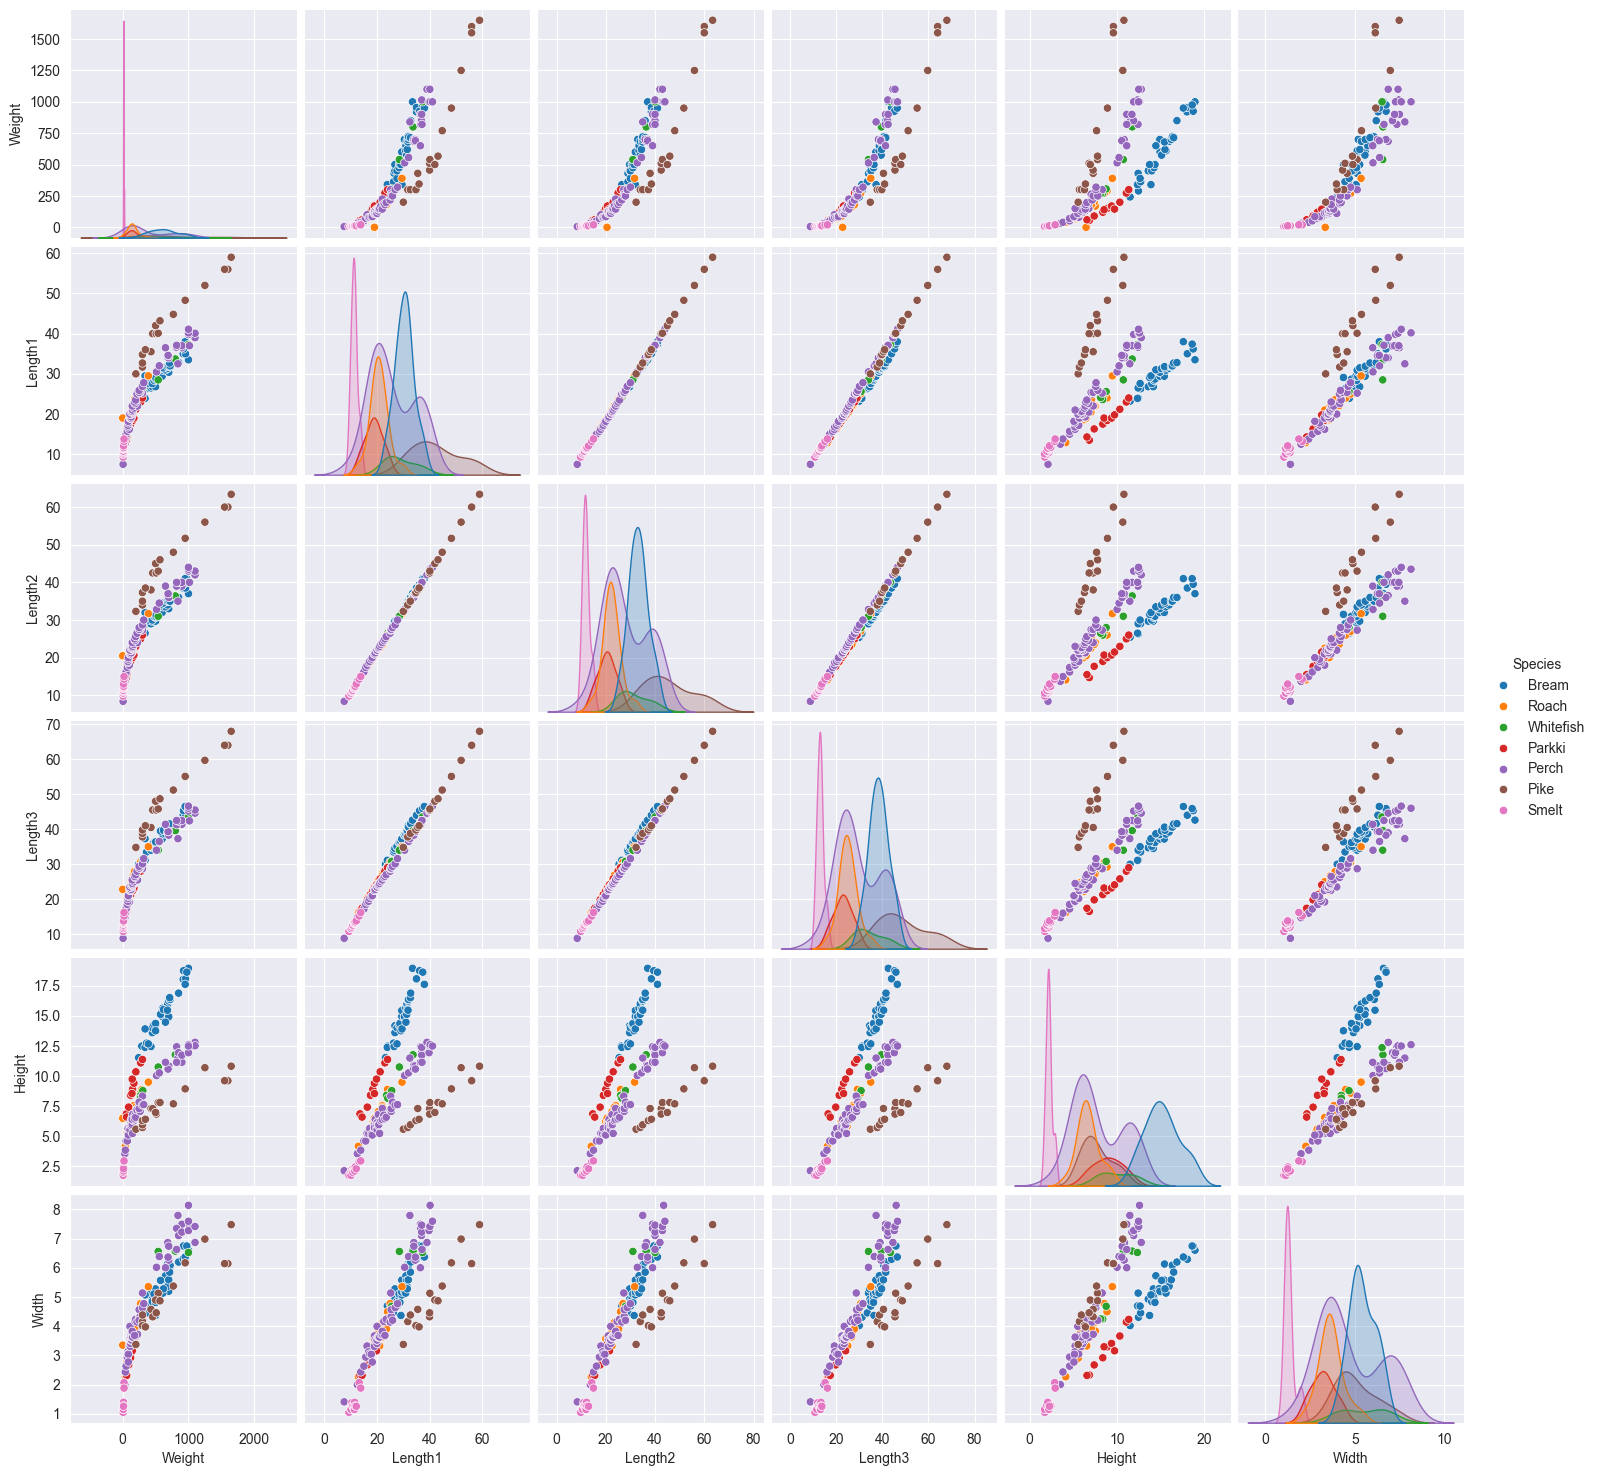

In [3]:
import seaborn as sns

sns.pairplot(df, hue='Species')

In [4]:
df.shape

(159, 7)

<Axes: xlabel='count', ylabel='Species'>

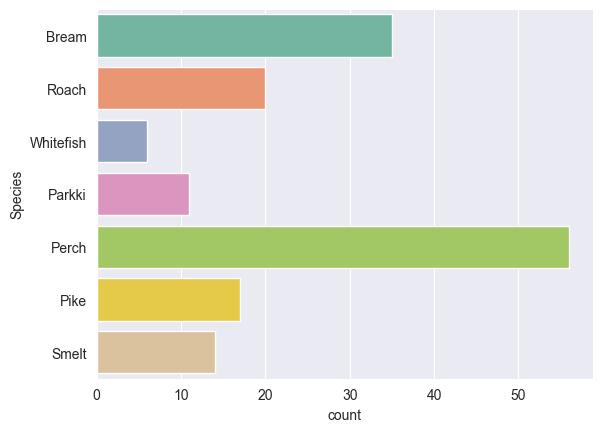

In [5]:
sns.countplot(df['Species'], legend=True, palette='Set2')

In [6]:
# are there duplicates?
df[df.duplicated() == True]
# no

,Species,Weight,Length1,Length2,Length3,Height,Width


<Axes: ylabel='count'>

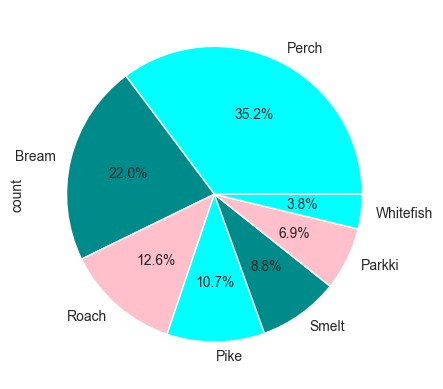

In [7]:
#PIE CHART

# Plotly Libraris
import plotly.express as px
import plotly.graph_objects as go

df['Species'].value_counts().plot.pie(autopct='%1.1f%%', colors=['cyan', 'darkcyan', 'pink'])

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

uniques = df.Species.unique()
d = dict(zip(uniques, range(len(uniques))))
lbe = LabelEncoder()
df['Target'] = lbe.fit_transform(df.Species)
df.drop('Species', axis=1, inplace=True)


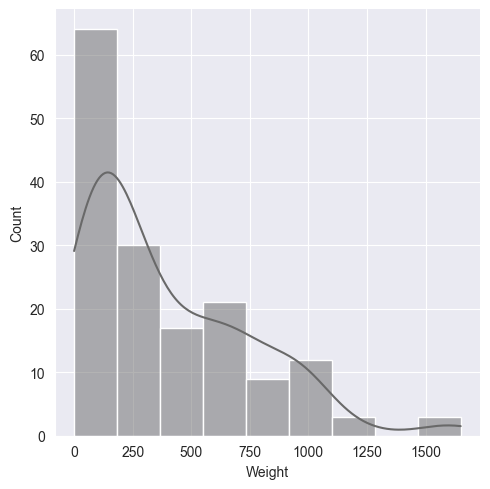

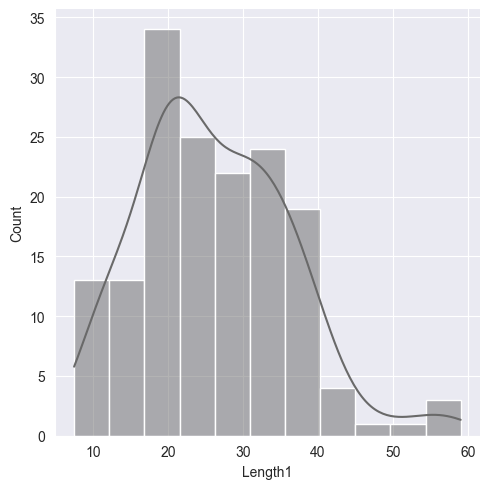

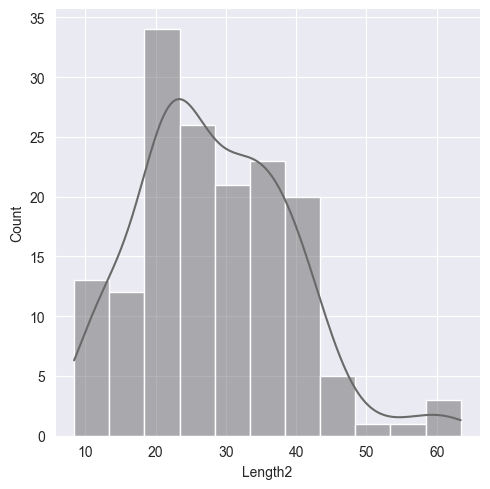

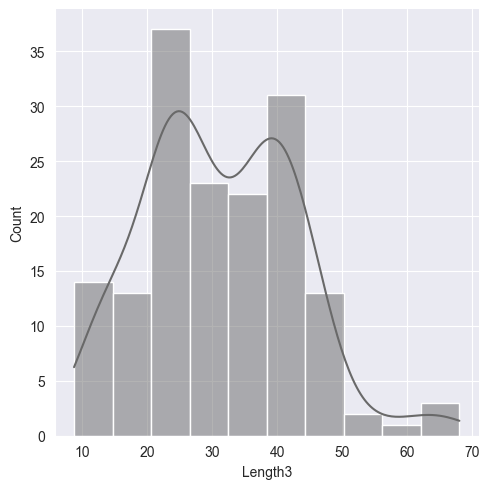

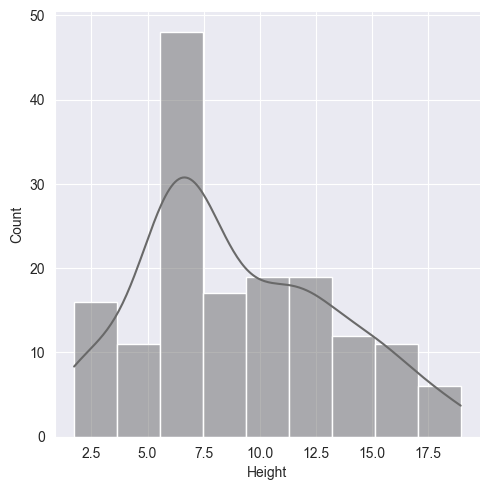

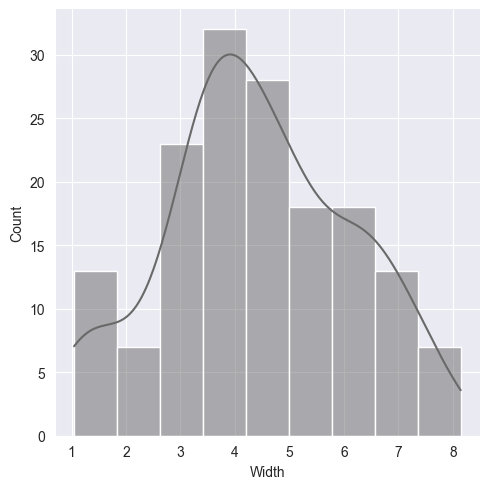

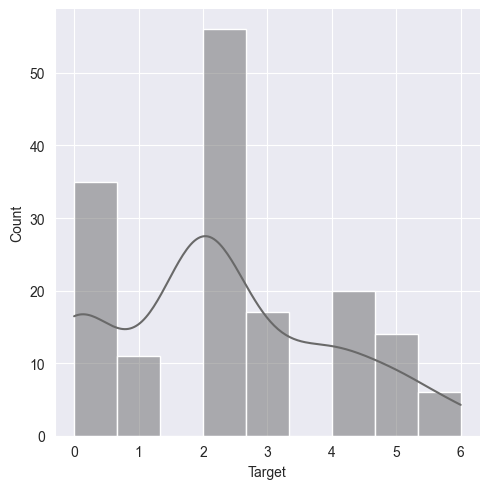

In [9]:
for col in df.columns:
    sns.displot(df[col], color="DimGrey", kde=True)


<Axes: >

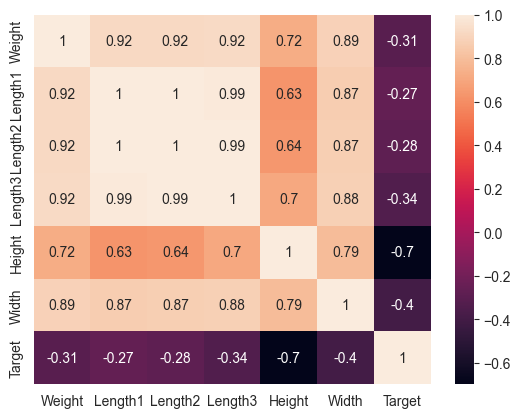

In [10]:
sns.heatmap(df.corr(), annot=True)

In [11]:

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor

scaler = StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(df.drop('Target', axis=1), df.Target, test_size=0.2,
                                                    random_state=42)
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)



In [12]:
from sklearn.metrics import mean_squared_error

linear = LinearRegression()
linear.fit(x_train_scaled, y_train)
linear.score(x_test_scaled, y_test)
score_error_train = mean_squared_error(y_train, linear.predict(x_train_scaled))
score_error_test = mean_squared_error(y_test, linear.predict(x_test_scaled))

In [13]:
r_2 = 1 - score_error_train / score_error_test
print(r_2)

0.5701621860331142


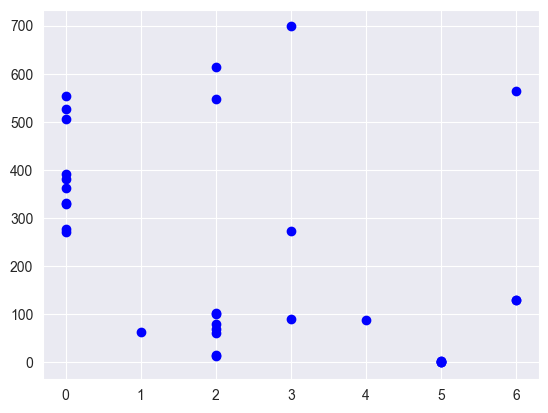

In [14]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.scatter(y_test, linear.predict(x_test), color='blue')

In [15]:
linear.predict(x_test).shape

(32,)

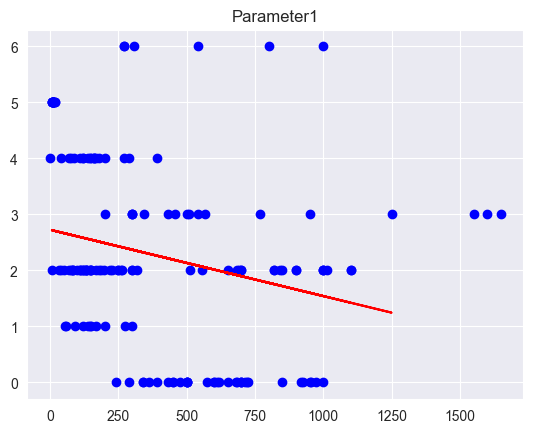

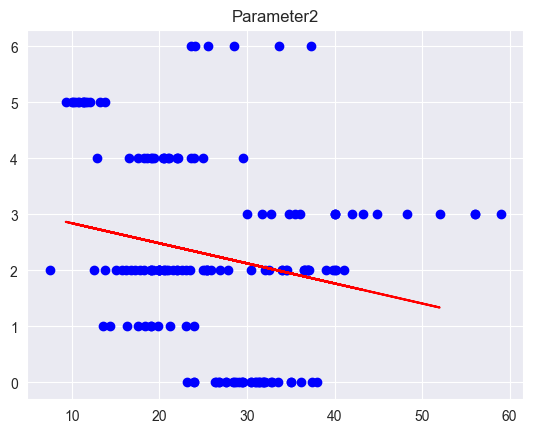

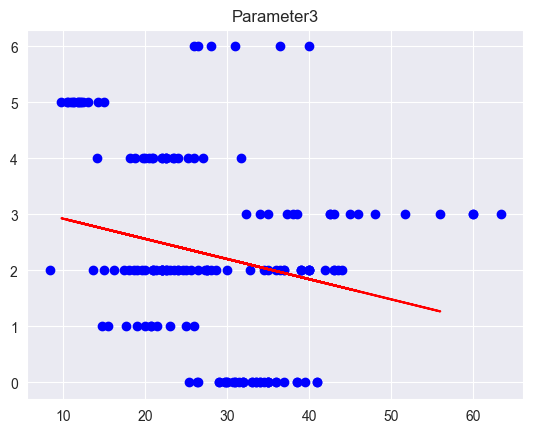

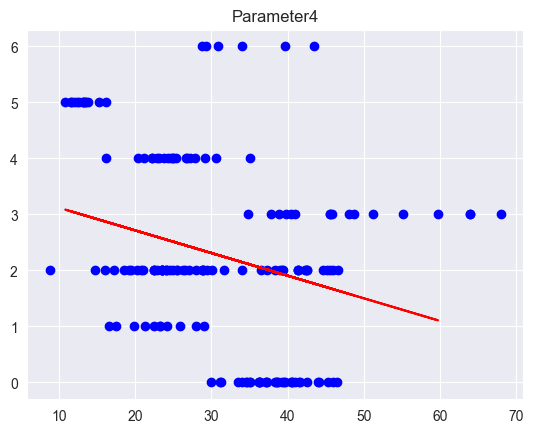

In [16]:
import numpy as np

lr = LinearRegression()

lr_r2 = []
lr_error = []
x = df.copy()
y = x.pop('Target')
for i in range(0, 4):
    X = np.array(x)[:, i]
    X = X.reshape(-1, 1)
    lr_x_train, lr_x_test, lr_y_train, lr_y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    lr.fit(lr_x_train, lr_y_train)

    score_r2_train = lr.score(lr_x_train, lr_y_train)
    score_r2_test = lr.score(lr_x_test, lr_y_test)
    lr_r2.append((i + 1, score_r2_train, score_r2_test))
    score_error_train = mean_squared_error(lr_y_train, lr.predict(lr_x_train)) ** 0.5
    score_error_test = mean_squared_error(lr_y_test, lr.predict(lr_x_test)) ** 0.5
    lr_error.append((i + 1, score_error_train, score_error_test))

    #Plot Linear
    fig, ax = plt.subplots()
    ax.scatter(X, y, color='blue')
    ax.plot(lr_x_test, lr.predict(lr_x_test), color='red')
    title = "Parameter" + str((i + 1))
    ax.set(title=title)

In [17]:

#Multivariate Linear Regression

mlr = LinearRegression()
mlr.fit(x_train, y_train)

score_r2_train = mlr.score(x_train, y_train)
score_r2_test = mlr.score(x_test, y_test)
score_error_train = mean_squared_error(y_train, mlr.predict(x_train))
score_error_test = mean_squared_error(y_test, mlr.predict(x_test))

lr_r2.append((7, score_r2_train, score_r2_test))
lr_error.append((7, score_error_train, score_error_test))
lr_r2 = np.asarray(lr_r2)
lr_error = np.asarray(lr_error)

[Text(0.5, 0, 'Umpteenth Parameter'),
 Text(0, 0.5, 'R2 Score'),
 Text(0.5, 1.0, 'R2 Score vs Parameter Used')]

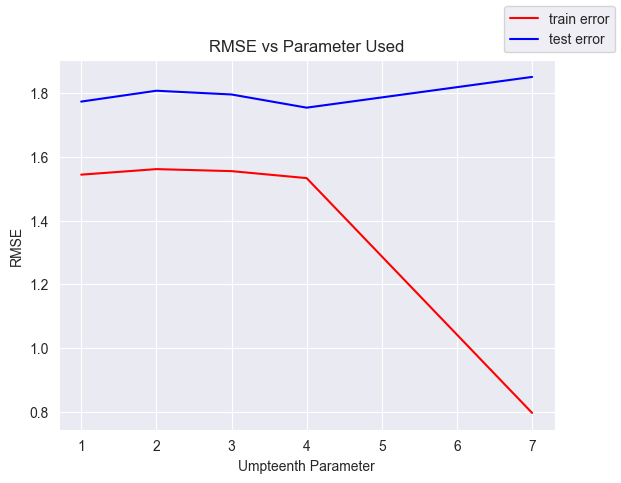

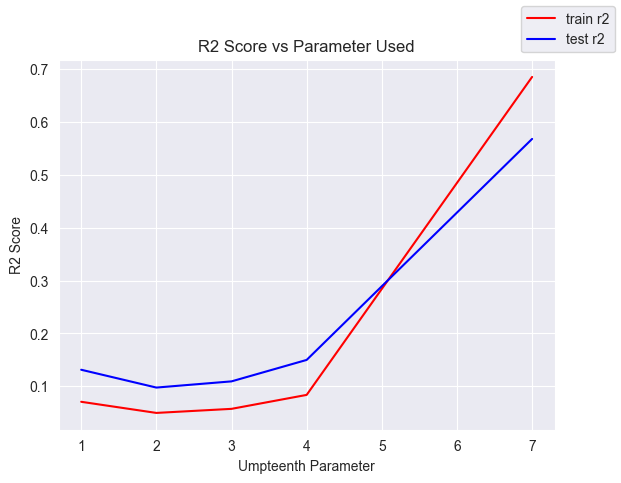

In [18]:
fig, ax = plt.subplots()
ax.plot(lr_error[:, 0], lr_error[:, 1], color='red');
ax.plot(lr_error[:, 0], lr_error[:, 2], color='blue');
fig.legend(["train error", "test error"], loc="upper right")
ax.xaxis.set_ticks(np.arange(1, 8, 1))
ax.set(xlabel='Umpteenth Parameter', ylabel='RMSE', title='RMSE vs Parameter Used');

fig, ax = plt.subplots()
ax.plot(lr_r2[:, 0], lr_r2[:, 1], color="red");
ax.plot(lr_r2[:, 0], lr_r2[:, 2], color="blue");
fig.legend(["train r2", "test r2"], loc="upper right")
ax.xaxis.set_ticks(np.arange(1, 8, 1))
ax.set(xlabel='Umpteenth Parameter', ylabel='R2 Score', title='R2 Score vs Parameter Used')

In [19]:
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

preprocessing = preprocessing.StandardScaler()
# full_pipeline = Pipeline([
#     ("preprocessing", preprocessing),
#     ("linear_regression", LinearRegression())])
# parameters = {"alpha": [1, 10, 100, 290, 500],
#               "fit_intercept": [True, False],
#               "solver": ['svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
#               }
#
# grid_search = GridSearchCV(full_pipeline, parameters,
#                            cv=5,
#                            scoring='neg_root_mean_squared_error')
# grid_search.fit(x_train, y_train)

In [20]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
parameters = {"fit_intercept": [False, True]
              }
reg.fit(x_train, y_train)
grid = GridSearchCV(estimator=reg, param_grid=parameters, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)
reg.score(x_test, y_test)

0.5682035669605443

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


# x_train_poly = poly.fit_transform(x_train)
# x_test_poly = poly.fit_transform(x_test)

poly_model = make_pipeline(PolynomialFeatures(), LinearRegression())
parameters = {"linearregression__fit_intercept": [False, True],
              "polynomialfeatures__degree": list(range(1, 10))}
poly_model.fit(x_train, y_train)
grid = GridSearchCV(estimator=poly_model, scoring='r2', param_grid=parameters, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('linearregression',
                                        LinearRegression())]),
             n_jobs=-1,
             param_grid={'linearregression__fit_intercept': [False, True],
                         'polynomialfeatures__degree': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9]},
             scoring='r2')

In [22]:
print(grid.best_params_)

{'linearregression__fit_intercept': False, 'polynomialfeatures__degree': 1}


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
steps = [("imputation", SimpleImputer(strategy="median")),
         ("logistic_regression", LogisticRegression())]
pipeline = Pipeline(steps)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train))
x_test_scaled = pd.DataFrame(scaler.transform(x_test))
pipeline.fit(x_train_scaled, y_train)

Pipeline(steps=[('imputation', SimpleImputer(strategy='median')),
                ('logistic_regression', LogisticRegression())])

In [68]:
from sklearn.model_selection import cross_val_score

round(cross_val_score(pipeline, pipeline.predict(x_test_scaled).reshape(-1, 1), y_test, scoring='accuracy', cv=5).mean(), 2)

np.float64(0.4)